Original Data Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Standardized Data (first 5 rows):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Reduced Data Shape: (150, 2)
Explained Variance Ratio: [0.72962445 0.22850762]


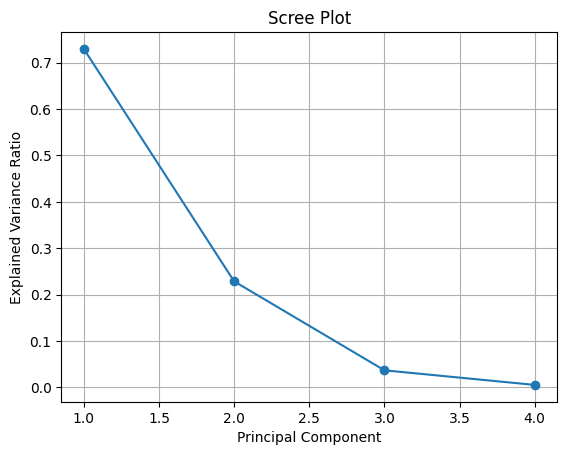

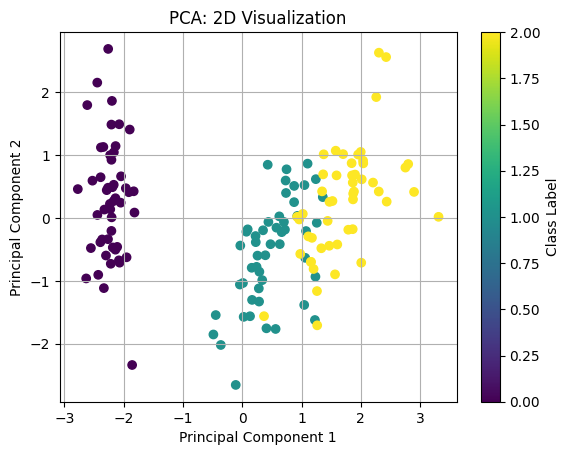

In [6]:
# ====================================================================
# Assignment No. 1: Perform PCA in dimension reduction of numerical data
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from sklearn.datasets import load_iris
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Original Data Shape:", X.shape)
print(X.head())

# ------------------------------------------
#  Data Standardization
# ------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized Data (first 5 rows):")
print(X_scaled[:5])

# ------------------------------------------
# Perform PCA to Reduce Dimension
# ------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nReduced Data Shape:", X_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# ------------------------------------------
# Construct Scree Plot
# ------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

plt.figure()
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.show()

# ------------------------------------------
# Data Visualization in Lower Dimension
# ------------------------------------------

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 2D Visualization")
plt.colorbar(label="Class Label")
plt.grid()
plt.show()